# Siparişler

✏️ **Alıştırma**

Bugün **siparişleri** ve bunlara ait **değerlendirme puanını (review score)** inceleyeceğiz.

👉 Amacımız aşağıdaki özelliklere sahip bir DataFrame oluşturmaktır:


| özellik_adı  	| tip  	| açıklama  	|
|:---	|:---:	|:---	|
| `order_id` 	| str 	| siparişin kimliği (id) 	|
| `wait_time` 	| float 	| `order_purchase_timestamp` ile `order_delivered_customer_date` arasındaki gün sayısı 	|
| `expected_wait_time` 	| float 	| `order_purchase_timestamp` ile `estimated_delivery_date` arasındaki beklenen gün sayısı 	|
| `delay_vs_expected` 	| float 	| gerçek `order_delivered_customer_date` tahmini teslim tarihinden sonra ise iki tarih arasındaki gün sayısını döndürür, aksi halde 0 döndürür 	|
| `order_status` 	| str 	| siparişin durumu 	|
| `dim_is_five_star` 	| int 	| sipariş beş yıldız aldıysa 1, aksi halde 0 	|
| `dim_is_one_star` 	| int 	| sipariş bir yıldız aldıysa 1, aksi halde 0 	|
| `review_score` 	| int 	| 1 ile 5 arasında 	|
| `number_of_items` 	| int 	| siparişin içerdiği toplam ürün sayısı 	|
| `number_of_sellers` 	| int 	| siparişte yer alan satıcı sayısı 	|
| `price` 	| float 	| müşterinin ödediği toplam sipariş fiyatı 	|
| `freight_value` 	| float 	| müşterinin ödediği kargo ücreti 	|
| `distance_customer_seller` 	| float 	| müşteri ile satıcı arasındaki mesafe (km, isteğe bağlı) 	|  

⚠️ Ayrıca "teslim edilmemiş" siparişleri filtrelemeliyiz; aksi belirtilmedikçe bunları dahil etmeyin, çünkü potansiyel gecikmeleri hesaplayamayız.

❓ **Senin görevin**: 

- Her bir özelliği `olist/order.py` içindeki `Order` sınıfında ayrı bir metod olarak uygulayın
- Ardından, eksiksiz DataFrame'i **`NaN` içermeyecek şekilde** döndüren `get_training_data()` metodunu oluşturun.

💡 Önerilen yöntem:
- Önce aşağıdaki notebook'u kullanarak kodunuzu adım adım yazıp test edin
- Kod mantığınızdan emin olduktan sonra kodu `order.py` dosyasına kopyalayın
- Şimdilik veri işleme mantığına odaklanın; veriyi görselleştirmeyi sonraki alıştırmalarda yapacağız

🔥 Notebook için en iyi uygulamalar (okumanız zorunludur) 👇

<details>
    <summary>▸ <i>tıklayın</i></summary>

Bundan sonra keşif amaçlı notebook'lar oldukça uzun olabilir; bu nedenle aşağıdaki ilkeleri takip etmenizi şiddetle tavsiye ediyoruz:
- Kodunuzu, Notebook her zaman baştan sona çalıştırıldığında çökmeden çalışacak şekilde yazın (Run --> Run All Cells)
- Değişken adlarını dikkatli seçin
- Kısa süreyle kullanılacak ara adımlar için `tmp` veya `_` gibi geçici isimler kullanın
- Notebook boyutunu azaltmak için kodunuzu temizleyin ve hücreleri birleştirin (`Shift-M`)
- Katlanabilir başlıklar ve içerik tablosunu sıkça kullanın (bulamazsanız bir TA'ya danışın)
- Aşağıdaki kısayolları kullanın
    - `a` bir hücre üstüne ekler
    - `b` bir hücre alta ekler
    - `dd` bir hücreyi siler
    - `esc` ve `ok` tuşları ile hücreler arası gezinme
    - `Shift-Enter` hücreyi çalıştırır ve sonraki hücreye geçer
    - parantez içindeyken örn. `groupby()` üzerinde `Shift + Tab` kullanarak dokümantasyona bakabilirsiniz. Birkaç kez tekrar edin, kalıcı olarak açmak için

</details>

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

# 1. ESKİ YOLLARI TEMİZLE (data-context-and-setup içeren yolları sil)
# Bu satır, eski projeye giden tüm köprüleri yakar.
sys.path = [p for p in sys.path if "data-context-and-setup" not in p]

# 2. MEVCUT KLASÖRÜ EKLE
# Şu an çalıştığın klasörü (data-orders) listenin en başına koyar.
current_path = os.getcwd()
if current_path not in sys.path:
    sys.path.insert(0, current_path)

# 3. KONTROL ET
import olist.order
from olist.data import Olist
print("✅ Şu an kullanılan dosya:", olist.order.__file__)

✅ Şu an kullanılan dosya: /Users/berkayturhan/data-orders/olist/order.py


In [2]:
# Auto reload imported module every time a jupyter cell is executed (handy for olist.order.py updates)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
# Import usual modules
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
%matplotlib inline

In [5]:
# Import olist data
from olist.data import Olist
olist = Olist()
data = olist.get_data()

In [6]:
# What datasets do we have access to now ?
data.keys()

dict_keys(['sellers', 'product_category_name_translation', 'orders', 'order_items', 'customers', 'geolocation', 'order_payments', 'order_reviews', 'products'])

In [7]:
orders = data['orders'].copy() # good practice to be sure not to modify your `data` variable

assert(orders.shape == (99441, 8))

## 1. `order.py` dosyasını kodlayın

### a) `get_wait_time`
    ❓ Aşağıyı döndüren bir DataFrame oluşturun:
           `order_id`, `wait_time`, `expected_wait_time`, `delay_vs_expected`, `order_status`



🎁 Bu ilk metod için aşağıda size pseudo-kod veriyoruz 👇

> 1. `orders` DataFrame'ini inceleyin
2. DataFrame'i `teslim edilmiş (delivered)` siparişler üzerine filtreleyin
3. `datetime` ile çalışmayı düzenleyin
    - Python [`datetime`](https://docs.python.org/3/library/datetime.html) nesnelerinin ne olduğunu anlamaya zaman ayırın
    - ve tarihleri "string" tipinden `pandas.to_datetime()` kullanarak `pandas.datetime` tipine dönüştürün
4. `order_purchase_timestamp`'tan başlayarak `wait_time`'ı gün cinsinden ondalıklı bir sayı olarak hesaplayın
5. `expected_wait_time`'ı `order_purchase_timestamp`'tan başlayarak gün cinsinden hesaplayın
6. `delay_vs_expected`'i gün cinsinden hesaplayın (sipariş tahmini teslim tarihinden daha erken teslim edildiyse 0 koyun)
7. Yeni DataFrame'i kontrol edin
8. Kodunuzdan memnun kaldığınızda, notebook'tan `olist/order.py`'ye dikkatlice kopyalayabilirsiniz
9. Şimdi metodunuzu `orders.py` içinde çağırmayı deneyin
10. Kodunuz muhtemelen hemen çalışmayacaktır
11. `.py` dosyası içinde çalışacak şekilde gerekli değişiklikleri yapın

`wait_time`, `expected_wait_time` ve `delay_vs_expected`'in tam sayı değil ondalıklı gün cinsinden olmasını istiyoruz. Düşünün: 8.1 veya 8.9 günlük bir bekleme büyük fark yaratır. Bu yüzden Pandas'ın `dt.day` özelliklerini kullanmayın; çünkü bu değerleri aşağı yuvarlar.

<details>
    <summary>💡İpucu</summary>

Hem `wait_time` hem de `delay_vs_expected` için ilgili tarihler arasındaki farkı almak üzere tarihleri çıkarmanız gerekir. Ardından bu farkın kaç günü temsil ettiğini bulmak için ya [`datetime.timedelta()`](https://docs.python.org/3/library/datetime.html#timedelta-objects) ya da [`np.timedelta64()`](https://numpy.org/doc/stable/reference/arrays.datetime.html#datetime-and-timedelta-arithmetic) kullanabilirsiniz!

</details>

In [8]:
# 1. Orders verisini çek ve kopyasını al
orders = data['orders'].copy()

# 2. Sadece teslim edilmiş ('delivered') siparişleri al
orders = orders[orders['order_status'] == 'delivered']

# 3. Tarih sütunlarını datetime formatına çevir (Hesaplama yapabilmek için şart)
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# 4. wait_time (Teslim edilme - Satın alma)
# 24 saate bölüyoruz ki sonucu "gün" cinsinden alalım.
one_day = np.timedelta64(24, 'h')
orders['wait_time'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']) / one_day

# 5. expected_wait_time (Tahmini teslim - Satın alma)
orders['expected_wait_time'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']) / one_day

# 6. delay_vs_expected (Gerçekleşen teslim - Tahmini teslim)
orders['delay_vs_expected'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']) / one_day

# Eğer sipariş erken geldiyse gecikme negatiftir, onu 0 yapalım (Ceza yok).
orders.loc[orders['delay_vs_expected'] < 0, 'delay_vs_expected'] = 0

# 7. Sonuçları göster
orders[['order_id', 'wait_time', 'expected_wait_time', 'delay_vs_expected', 'order_status']].head()

,order_id,wait_time,expected_wait_time,delay_vs_expected,order_status
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,0.0,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,0.0,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,0.0,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,0.0,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,0.0,delivered


In [9]:
import olist.order
print(olist.order.__file__)

/Users/berkayturhan/data-orders/olist/order.py


👀 Oluşturduğunuz DataFrame'i kontrol edin.  

💪 Kodunuz çalıştığında, kodunuzu `olist/order.py` içine taşıyın  

🧪 Şimdi aşağıdaki hücreyi çalıştırarak test edin 👇

In [10]:
# Test your code here
from olist.order import Order
Order().get_wait_time()

,order_id,wait_time,expected_wait_time,delay_vs_expected,order_status
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,0.0,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,0.0,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,0.0,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,0.0,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,0.0,delivered
...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,8.218009,18.587442,0.0,delivered
99437,63943bddc261676b46f01ca7ac2f7bd8,22.193727,23.459051,0.0,delivered
99438,83c1379a015df1e13d02aae0204711ab,24.859421,30.384225,0.0,delivered
99439,11c177c8e97725db2631073c19f07b62,17.086424,37.105243,0.0,delivered


In [11]:
from nbresult import ChallengeResult
test = Order().get_wait_time()
result = ChallengeResult('wait_time', dve_type=test["delay_vs_expected"].dtype, shape=test.shape, dve_min=test["delay_vs_expected"].min(), dve_max=test["delay_vs_expected"].max())
result.write(); print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/berkayturhan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/berkayturhan/data-orders
configfile: pytest.ini
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_wait_time.py::TestWaitTime::test_wait_time PASSED                   [100%]

============================== 1 passed in 0.09s ===============================


💯 You can commit your code:

git add tests/wait_time.pickle

git commit -m 'Completed wait_time step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### b) `get_review_score`
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `dim_is_five_star`, `dim_is_one_star`, `review_score`

`dim_is_$N$_star` sütunu `review_score=$N$` ise `1`, değilse `0` içermelidir

<details>
    <summary markdown='span'>İpuçları</summary>

`Series.map()` veya `DataFrame.apply()` üzerine düşünün
    
</details>

👉 We load the `reviews` for you

In [12]:
reviews = data['order_reviews'].copy()
assert(reviews.shape == (99224,7))
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [13]:
# 1. Veriyi çek
reviews = data['order_reviews'].copy()

# 2. dim_is_five_star (Eğer puan 5 ise 1, değilse 0 olsun)
# (reviews['review_score'] == 5) kısmı True/False döndürür.
# .astype(int) kısmı True'yu 1, False'u 0 yapar.
reviews['dim_is_five_star'] = (reviews['review_score'] == 5).astype(int)

# 3. dim_is_one_star (Eğer puan 1 ise 1, değilse 0 olsun)
reviews['dim_is_one_star'] = (reviews['review_score'] == 1).astype(int)

# 4. Sadece istenen sütunları seç
# order_id, dim_is_five_star, dim_is_one_star, review_score
reviews = reviews[['order_id', 'dim_is_five_star', 'dim_is_one_star', 'review_score']]

# 5. Sonucu göster
reviews.head()

,order_id,dim_is_five_star,dim_is_one_star,review_score
0,73fc7af87114b39712e6da79b0a377eb,0,0,4
1,a548910a1c6147796b98fdf73dbeba33,1,0,5
2,f9e4b658b201a9f2ecdecbb34bed034b,1,0,5
3,658677c97b385a9be170737859d3511b,1,0,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,1,0,5


Yine,

👀 Oluşturduğunuz DataFrame'i kontrol edin.  

💪 Kodunuz çalıştığında, kodunuzu `olist/order.py` içine taşıyın  

🧪 Şimdi aşağıdaki hücreyi çalıştırarak test edin 👇

In [14]:
# Test your code here
from olist.order import Order
Order().get_review_score()

,order_id,dim_is_five_star,dim_is_one_star,review_score
0,73fc7af87114b39712e6da79b0a377eb,0,0,4
1,a548910a1c6147796b98fdf73dbeba33,1,0,5
2,f9e4b658b201a9f2ecdecbb34bed034b,1,0,5
3,658677c97b385a9be170737859d3511b,1,0,5
4,8e6bfb81e283fa7e4f11123a3fb894f1,1,0,5
...,...,...,...,...
99219,2a8c23fee101d4d5662fa670396eb8da,1,0,5
99220,22ec9f0669f784db00fa86d035cf8602,1,0,5
99221,55d4004744368f5571d1f590031933e4,1,0,5
99222,7725825d039fc1f0ceb7635e3f7d9206,0,0,4


In [15]:
from nbresult import ChallengeResult
result = ChallengeResult('review_score', shape=Order().get_review_score().shape)
result.write(); print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/berkayturhan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/berkayturhan/data-orders
configfile: pytest.ini
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_review_score.py::TestReviewScore::test_review_score PASSED          [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/review_score.pickle

git commit -m 'Completed review_score step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### c) `get_number_items`:
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `number_of_items` (her sipariş için toplam ürün sayısı)

In [16]:
# 1. Veriyi çek
items = data['order_items'].copy()

# 2. Sipariş başına ürün sayısını bul
items = items.groupby('order_id').agg({'product_id': 'count'})

# 3. Sütun ismini güncelle
items.rename(columns={'product_id': 'number_of_items'}, inplace=True)

# 4. KRİTİK ADIM: Index'i sütuna çevir!
items.reset_index(inplace=True)

# 5. Sonucu gör (Artık order_id bir sütun olmalı)
items.head()

,order_id,number_of_items
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1


🧪 Aynı rutin:
* DataFrame'inizi kontrol edin,
* Kodunuzu `olist/order.py` içine taşıyın
* ve gerçekten çalıştığını doğrulayın.

In [17]:
from nbresult import ChallengeResult
result = ChallengeResult('number_items',
                         shape=Order().get_number_items().shape,
                         columns=Order().get_number_items().columns)
result.write(); print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/berkayturhan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/berkayturhan/data-orders
configfile: pytest.ini
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_number_items.py::TestNumberItems::test_column_names PASSED          [ 50%]
test_number_items.py::TestNumberItems::test_number_items PASSED          [100%]

============================== 2 passed in 0.46s ===============================


💯 You can commit your code:

git add tests/number_items.pickle

git commit -m 'Completed number_items step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### d) `get_number_sellers`:
     ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `number_of_sellers` (her sipariş için benzersiz satıcı sayısı)
        
<details>
    <summary>▸ <i>İpucu</i></summary>

`pd.Series.nunique()` metoduna bakın
</details>

In [18]:
# 1. Veriyi çek
sellers = data['order_items'].copy()

# 2. Sipariş başına BENZERSİZ satıcı sayısını bul
# 'nunique' = Number of Unique (Benzersiz Sayısı)
sellers = sellers.groupby('order_id').agg({'seller_id': 'nunique'})

# 3. Sütun ismini değiştir
sellers.rename(columns={'seller_id': 'number_of_sellers'}, inplace=True)

# 4. Index'i sütuna çevir (Bunu artık ezberledik 😉)
sellers.reset_index(inplace=True)

# 5. Sonucu gör
sellers.head()

,order_id,number_of_sellers
0,00010242fe8c5a6d1ba2dd792cb16214,1
1,00018f77f2f0320c557190d7a144bdd3,1
2,000229ec398224ef6ca0657da4fc703e,1
3,00024acbcdf0a6daa1e931b038114c75,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,1


In [19]:
from nbresult import ChallengeResult
result = ChallengeResult('number_sellers',
                         shape=Order().get_number_sellers().shape,
                         columns=Order().get_number_sellers().columns)
result.write(); print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/berkayturhan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/berkayturhan/data-orders
configfile: pytest.ini
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_number_sellers.py::TestNumberSellers::test_column_names PASSED      [ 50%]
test_number_sellers.py::TestNumberSellers::test_number_seller PASSED     [100%]

============================== 2 passed in 0.38s ===============================


💯 You can commit your code:

git add tests/number_sellers.pickle

git commit -m 'Completed number_sellers step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

### e) `get_price_and_freight`
     Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `price`, `freight_value`

In [20]:
# 1. Veriyi çek
data = Olist().get_data()
price = data['order_items'].copy()

# 2. Sipariş bazında grupla ve Fiyatları/Kargoları TOPLA (sum)
# İsim değişikliği istenmediği için direkt sum() yapıyoruz.
price = price.groupby('order_id')[['price', 'freight_value']].sum()

# 3. Index'i sütuna çevir (order_id sütun olsun)
price.reset_index(inplace=True)

# 4. Sonucu gör
price.head()

,order_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14


In [21]:
from nbresult import ChallengeResult
result = ChallengeResult('price', shape=Order().get_price_and_freight().shape)
result.write(); print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/berkayturhan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/berkayturhan/data-orders
configfile: pytest.ini
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_price.py::TestPrice::test_price PASSED                              [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/price.pickle

git commit -m 'Completed price step'

git push origin master



⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!

## 2. Hepsini bir arada: `get_training_data`

❓ Daha önce kodladığınız metodları kullanarak `get_training_data` metodunu yazma zamanı; tüm sipariş özelliklerini tek bir tabloda toplayın.

In [22]:
# 1. Sınıfı çağır
order = Order()

# 2. Tüm parçaları tek tek getir
training_data = order.get_wait_time(is_delivered=True)
reviews = order.get_review_score()
items = order.get_number_items()
sellers = order.get_number_sellers()
price = order.get_price_and_freight()

# 3. Hepsini 'order_id' üzerinden zincirleme birleştir (Merge)
training_data = training_data.merge(reviews, on='order_id') \
                             .merge(items, on='order_id') \
                             .merge(sellers, on='order_id') \
                             .merge(price, on='order_id')

# 4. Eksik verisi olan satırları at (Temiz eğitim verisi için şart)
training_data = training_data.dropna()

# 5. Sonucu gör
training_data.head()

,order_id,wait_time,expected_wait_time,delay_vs_expected,order_status,dim_is_five_star,dim_is_one_star,review_score,number_of_items,number_of_sellers,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,15.544063,0.0,delivered,0,0,4,1,1,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,19.137766,0.0,delivered,0,0,4,1,1,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,26.639711,0.0,delivered,1,0,5,1,1,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,26.188819,0.0,delivered,1,0,5,1,1,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,12.112049,0.0,delivered,1,0,5,1,1,19.90,8.72


🧪 Aşağıda test edin

In [23]:
from nbresult import ChallengeResult
from olist.order import Order
data = Order().get_training_data()

result = ChallengeResult('training',
    shape=data.shape,
    columns=sorted(list(data.columns))
)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/berkayturhan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/berkayturhan/data-orders
configfile: pytest.ini
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 2 items

test_training.py::TestTraining::test_training_data_columns PASSED        [ 50%]
test_training.py::TestTraining::test_training_data_shape PASSED          [100%]

============================== 2 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/training.pickle

git commit -m 'Completed training step'

git push origin master



💡 **Beklenen satır sayısını elde edemiyor musunuz?**
<details><summary>8 satırlık bir fark mı var?</summary>
Sonuçta `NaN` içermeyen bir DataFrame istiyoruz. `NaN`'ları kaldırmayı deneyin. (Çok karmaşık hale getirmeyin: genelde kodunuzda bir satırı değiştirmeniz yeterlidir.)
</details>
<details><summary>Başka bir fark mı var?</summary>
Belki tüm adımları tek bir DataFrame'de birleştirirken bir şey yanlış gitmiştir? Birleştirmelerinizi (merge) kontrol edin.
</details>

🏁 Tebrikler! 

💾 Notebook'unuzu ve `olist/order.py` içindeki kodunuzu commit edip pushlayın, sonra sonraki alıştırmaya geçin.

## 3. [İSTEĞE BAĞLI] `get_distance_seller_customer` 
**Bu fonksiyonu yalnızca bugünkü alıştırmaları bitirdikten sonra yazmayı deneyin.**

**Önce bir sonraki alıştırmaya geçin.**

    ❓ Aşağıyı döndüren bir DataFrame oluşturun:
        `order_id`, `distance_seller_customer` (müşteri ile satıcı arasındaki mesafe, km cinsinden)

💡 `olist.utils` modülünde sizin için yazılmış `haversine_distance` formülüne göz atın

Bunu kullanarak `get_distance_seller_customer`'ı kodlayın.

⚠️ Bir sipariş birden fazla satıcı içerebileceği için, sipariş başına ortalama satıcı-müşteri mesafesini alın.

In [24]:
from olist.utils import haversine_distance

# 1. Gerekli tüm verileri çekelim
data = Olist().get_data()
orders = data['orders']
items = data['order_items']
sellers = data['sellers']
customers = data['customers']
geo = data['geolocation']

# 2. Sadece teslim edilenleri alalım
orders = orders[orders['order_status'] == 'delivered']

# 3. Geo verisini tekilleştirelim (Her posta kodu için tek bir lat/lon olsun)
# (Brezilya'da aynı posta kodunda birden fazla koordinat olabiliyor, ilkini alıyoruz)
geo = geo.groupby('geolocation_zip_code_prefix').first().reset_index()

# 4. BÜYÜK BİRLEŞTİRME (Merge Chain)
# Orders -> Items -> Sellers -> Customers
merged = orders.merge(items, on='order_id') \
               .merge(sellers, on='seller_id') \
               .merge(customers, on='customer_id')

# 5. Müşteri Koordinatlarını Ekle (Customer Zip -> Geo Zip)
merged = merged.merge(geo, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')
merged.rename(columns={'geolocation_lat': 'c_lat', 'geolocation_lng': 'c_lng'}, inplace=True)

# 6. Satıcı Koordinatlarını Ekle (Seller Zip -> Geo Zip)
merged = merged.merge(geo, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left')
merged.rename(columns={'geolocation_lat': 's_lat', 'geolocation_lng': 's_lng'}, inplace=True)

# 7. Eksik verileri (koordinatı bulunamayanları) atalım
merged = merged.dropna(subset=['c_lat', 'c_lng', 's_lat', 's_lng'])

# 8. Mesafeyi Hesapla (Haversine Formülü)
# haversine_distance fonksiyonu (lng1, lat1, lng2, lat2) sırasıyla alır
merged['distance_seller_customer'] = merged.apply(
    lambda row: haversine_distance(row['c_lng'], row['c_lat'], row['s_lng'], row['s_lat']), 
    axis=1
)

# 9. Sipariş başına ortalama mesafeyi al
final_data = merged.groupby('order_id').agg({'distance_seller_customer': 'mean'}).reset_index()

# 10. Sonucu gör
final_data.head()

,order_id,distance_seller_customer
0,00010242fe8c5a6d1ba2dd792cb16214,301.005664
1,00018f77f2f0320c557190d7a144bdd3,589.274140
2,000229ec398224ef6ca0657da4fc703e,312.495046
3,00024acbcdf0a6daa1e931b038114c75,301.951753
4,00042b26cf59d7ce69dfabb4e55b4fd9,646.221788


In [27]:
matching_geo = Order().get_distance_seller_customer()

👉 Hemen satıcı-müşteri mesafesinin dağılımını hızlıca inceleyelim :)

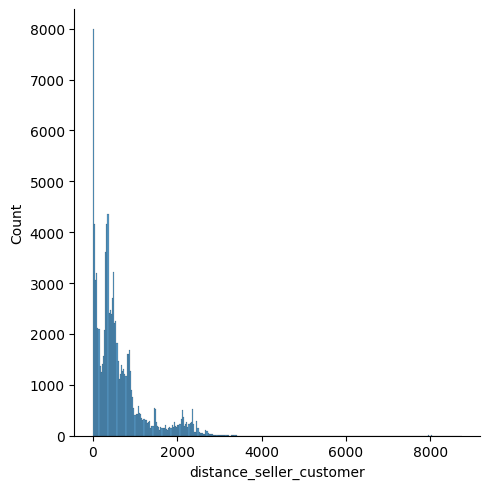

In [28]:
sns.displot(data = matching_geo, x ='distance_seller_customer')

👉 Satıcı-müşteri mesafesinin medyanı ve ortalaması nedir?

In [29]:
matching_geo['distance_seller_customer'].describe()

count    96002.000000
mean       601.070608
std        595.476894
min          0.000000
25%        186.685875
50%        433.846117
75%        797.871901
max       8736.947618
Name: distance_seller_customer, dtype: float64

👀 Yeni DataFrame'inizi kontrol edin ve kod çalıştığında `olist/order.py` içine taşıyın.

In [30]:
Order().get_distance_seller_customer()['distance_seller_customer']

0         301.005664
1         589.274140
2         312.495046
3         301.951753
4         646.221788
            ...     
95997    2755.314485
95998     354.848852
95999     338.827218
96000      72.870476
96001     133.230980
Name: distance_seller_customer, Length: 96002, dtype: float64

🧪 Kodunuzu test edin

In [31]:
from nbresult import ChallengeResult

result = ChallengeResult('distance',
    mean = Order().get_distance_seller_customer()['distance_seller_customer'].mean())
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/berkayturhan/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/berkayturhan/data-orders
configfile: pytest.ini
plugins: anyio-4.8.0, typeguard-4.4.2
collecting ... collected 1 item

test_distance.py::TestDistance::test_distance PASSED                     [100%]

============================== 1 passed in 0.11s ===============================


💯 You can commit your code:

git add tests/distance.pickle

git commit -m 'Completed distance step'

git push origin master



Ayrıca `with_distance_seller_customer` `True` olarak ayarlandığında `get_training_data`'yı `get_distance_seller_customer` ile birleştirecek şekilde güncelleyin.

⚠️ `order.py` içindeki değişiklikleri `olist` deposuna commit etmeyi unutmayın!